In [1]:
import poppy
import jax

In [2]:
poppy.POLYNOMIAL[3329][4]=[3323,2345,1603,800,1]
poppy.POLYNOMIAL[3329][5]=[2801,3247,697,1403,2111,1]

In [3]:
# FINITE FIELD LATTICE BASED KEY ENCAPSULATION.
p = 3329 # is the field characteristic.
n = 4 # is the field degree. {4,5}
f = poppy.field(p,n, dtype = poppy.INT) # is the finite field.
N = 4 # is the number of bits in in a word.
k = 16 # is the square root of the number of words in the message. {4,8,16}
b = 1 # is the number of k*k word messages.
psd = poppy.SEED # is the public seed.
ssd = (908235,3209,4580,1,583981) # are secret seeds.
M = jax.numpy.tile(jax.numpy.arange(k*k, dtype = jax.numpy.uint8),b).reshape((b,k,k))%(2**N) # is the message.

In [4]:
def uniform(seed):
  # The public key is sampled from the uniform distribution.
  sample = jax.random.randint(jax.random.key(seed), (b,k,k,n), 0,f.p, dtype = poppy.INT)
  return sample
def normal(seed):
  # The private key, error, and randomness are sampled from a normal distribution.
  bits = jax.random.bits(jax.random.key(seed), shape = (b*k*k*n,1), dtype = jax.numpy.uint8)
  bitsream = jax.numpy.unpackbits(bits, axis = 1).reshape((b*k*k*n,2,4))
  sample = jax.numpy.sum(bitsream, axis = 2, dtype = poppy.INT)
  sample = jax.numpy.subtract(sample[:,0],sample[:,1]).reshape((b,k,k,n))%f.p
  return sample
def rep(a,b):
  return poppy.rep(a,b,p)
def add(a,b):
  return poppy.mod(a+b,p)
def sub(a,b):
  return poppy.mod(a-b,p)
def mul(a,b):
  return poppy.mod(a*b,p)
def matmul(a,b):
  return poppy.matmul55(a,b,p)
def outer(a,b):  
  return poppy.outer33(a,b,p)
def compress(a):
  return jax.numpy.astype(a,jax.numpy.uint16)
def decompress(a):
  return jax.numpy.astype(a,poppy.INT)
def encode(m):
  x = f.dual[0].reshape((1,1,1,n,n)) # Pick a field element with unit trace.
  c = f.p/(2**N)
  cm = jax.numpy.rint(c*m.reshape((b,k,k,1,1))) # Scale the message.
  mu = mul(cm,x) # Map the message to the field.
  return mu
def decode(mu):
  cm = poppy.trace(mu,f.p) # The message is in the trace.
  d = (2**N)/f.p
  m = jax.numpy.rint(d*cm)%(2**N) # Scale the message.
  m = jax.numpy.astype(m, jax.numpy.uint8)
  return m

@jax.jit
def keygen():
  sk  = rep(normal(ssd[0]),f.dual.swapaxes(1,2)) # b k k n n secret key.
  e1  = rep(normal(ssd[1]),f.basis)              # b k k n n error.
  pk1 = rep(uniform(psd),  f.dual)               # b k k n n public key.
  pk2 = add(matmul(pk1,sk),e1)                   # b k k n n public key.
  ek  = (compress(pk2),psd) # Encapsulation key.
  dk  =  compress(sk)       # Decapsulation key.
  return sk,e1,pk1,pk2, ek,dk

@jax.jit
def encrypt(m,ek):
  pk2,psd = ek
  pk1 = rep(uniform(psd),  f.dual)                # b k k n n public key.
  r   = rep(normal(ssd[2]),f.dual)                # b k k n n randomness.
  e2  = rep(normal(ssd[3]),f.basis.swapaxes(1,2)) # b k k n n error.
  e3  = rep(normal(ssd[4]),f.dual)                # b k k n n error.
  mu  = encode(m)                                 # b k k n n message.
  pk3 = add(matmul(r,pk1),e2)                     # b k k n n public key.
  ct  = add(matmul(r,decompress(pk2)),mu+e3)      # b k k n n cipher text.
  c   = (compress(pk3),compress(ct)) # Ciphertext.
  return r,e2,e3,pk3,mu,ct, c

@jax.jit
def decrypt(c,dk):
  pk3,ct = c
  mu = sub(decompress(ct),matmul(decompress(pk3),decompress(dk)))
  m = decode(mu)
  return mu, m

In [5]:
sk,e1,pk1,pk2, ek,dk = keygen()
r,e2,e3,pk3,MU,ct, c = encrypt(M,ek)
mu, m = decrypt(c,dk)

print(f'\nFIRST {M.shape[1]}x{M.shape[2]} WORD MESSAGE:')
print(M[0])
print('\nDECRYPTION ERROR:')
print((M-m)[0])


FIRST 16x16 WORD MESSAGE:
[[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]]

DECRYPTION ERROR:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

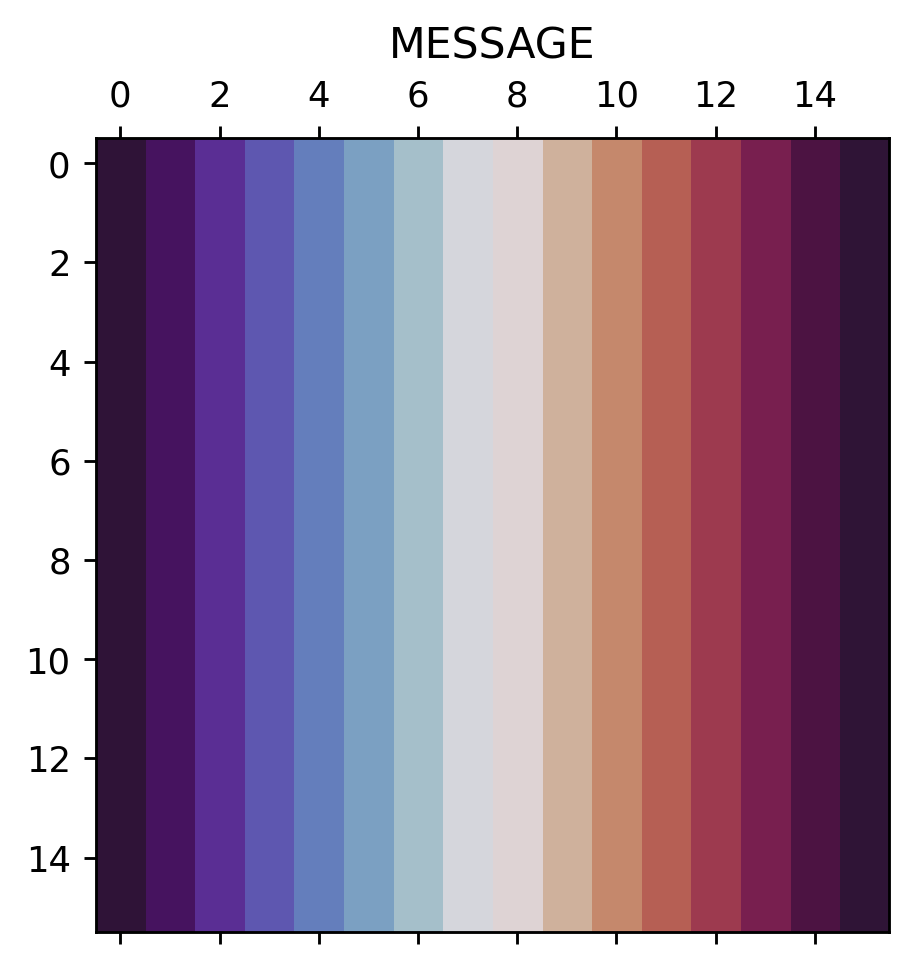

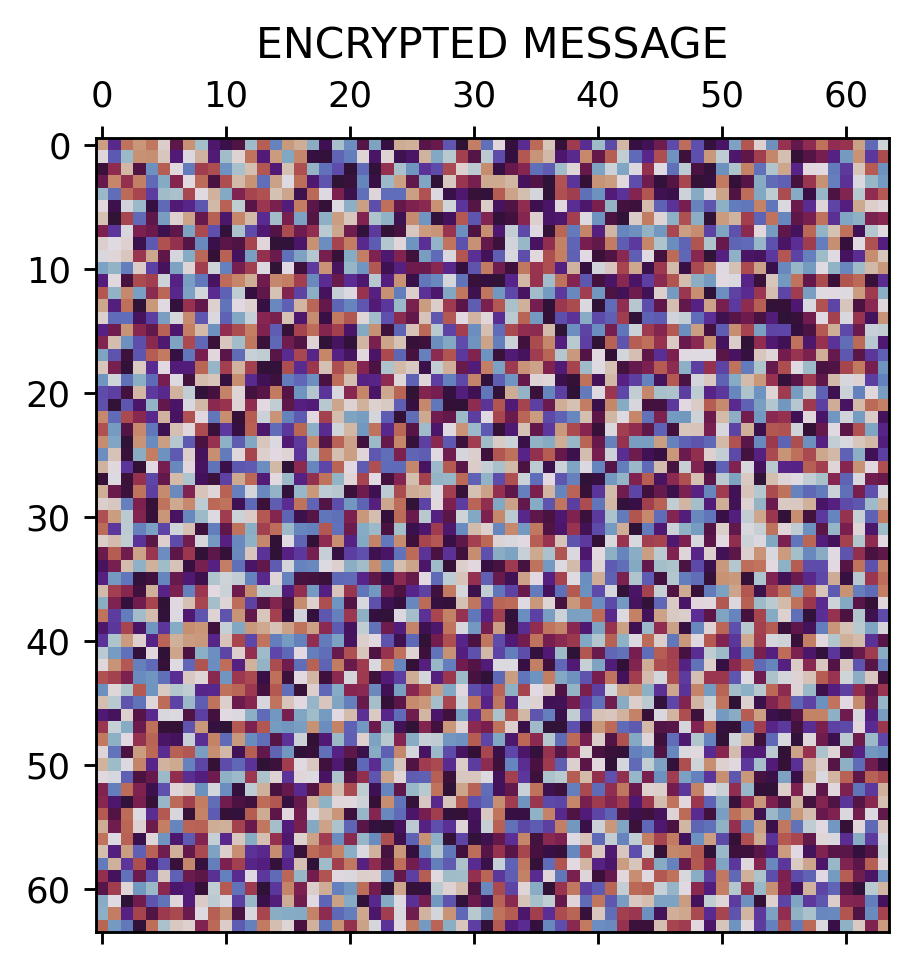

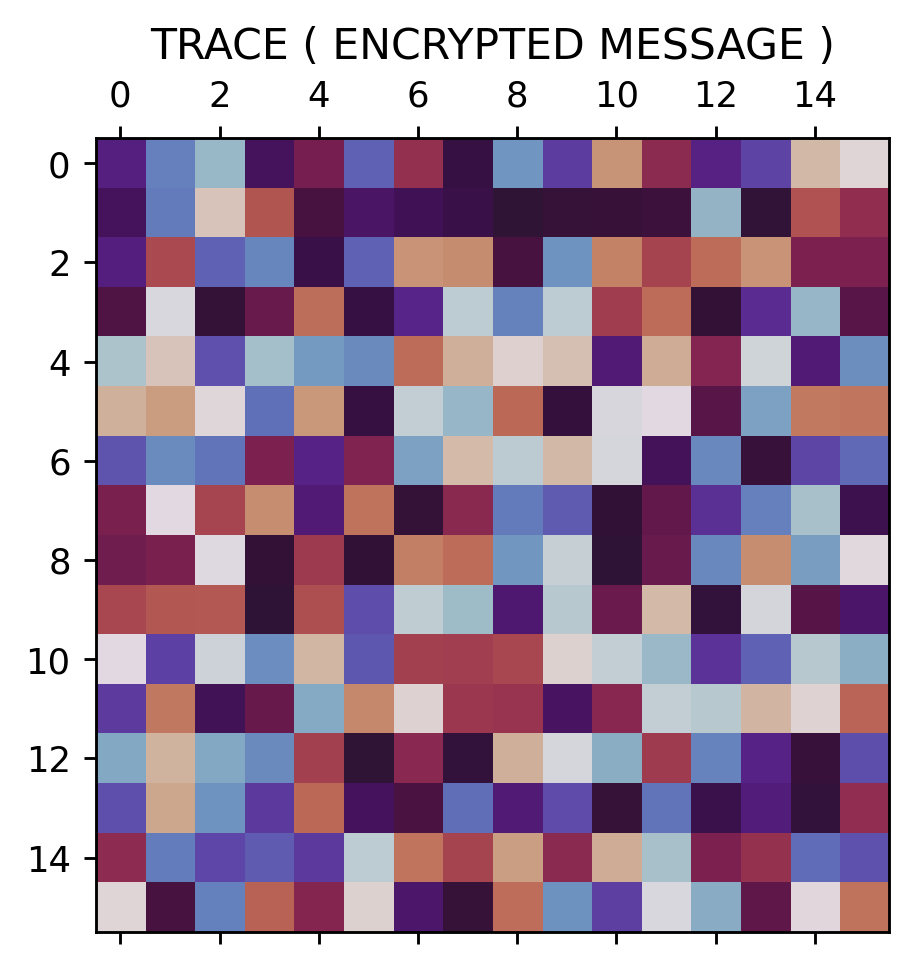

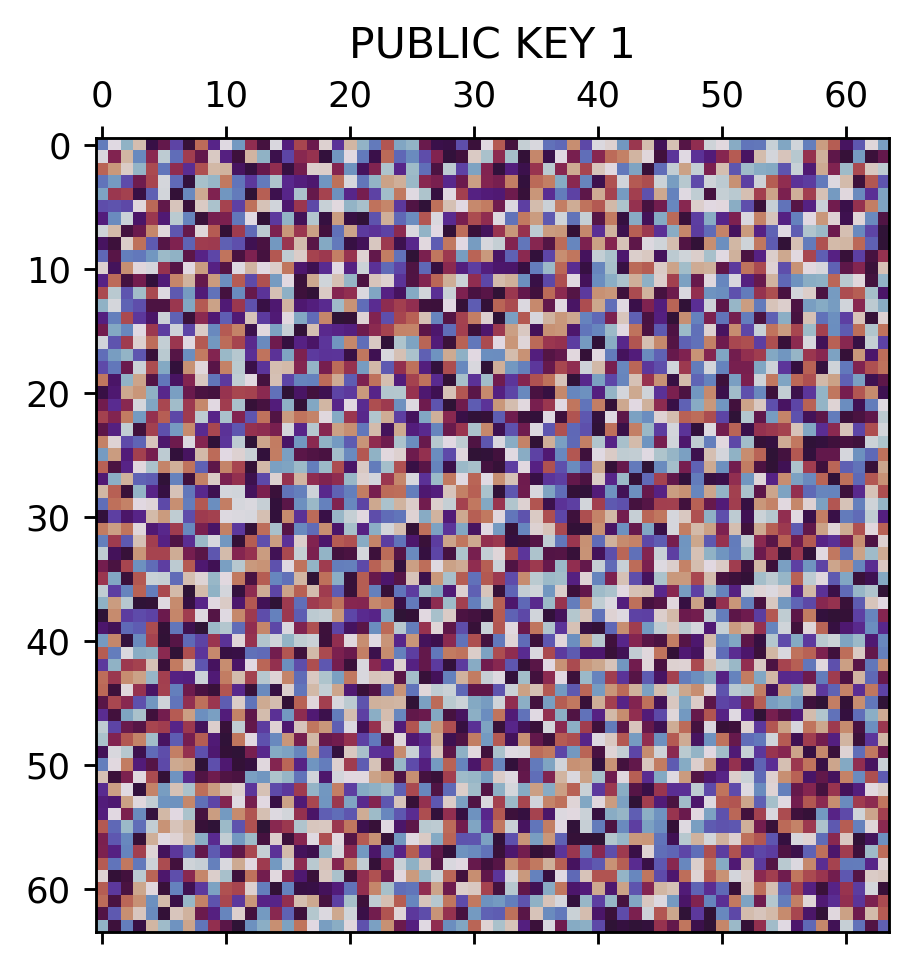

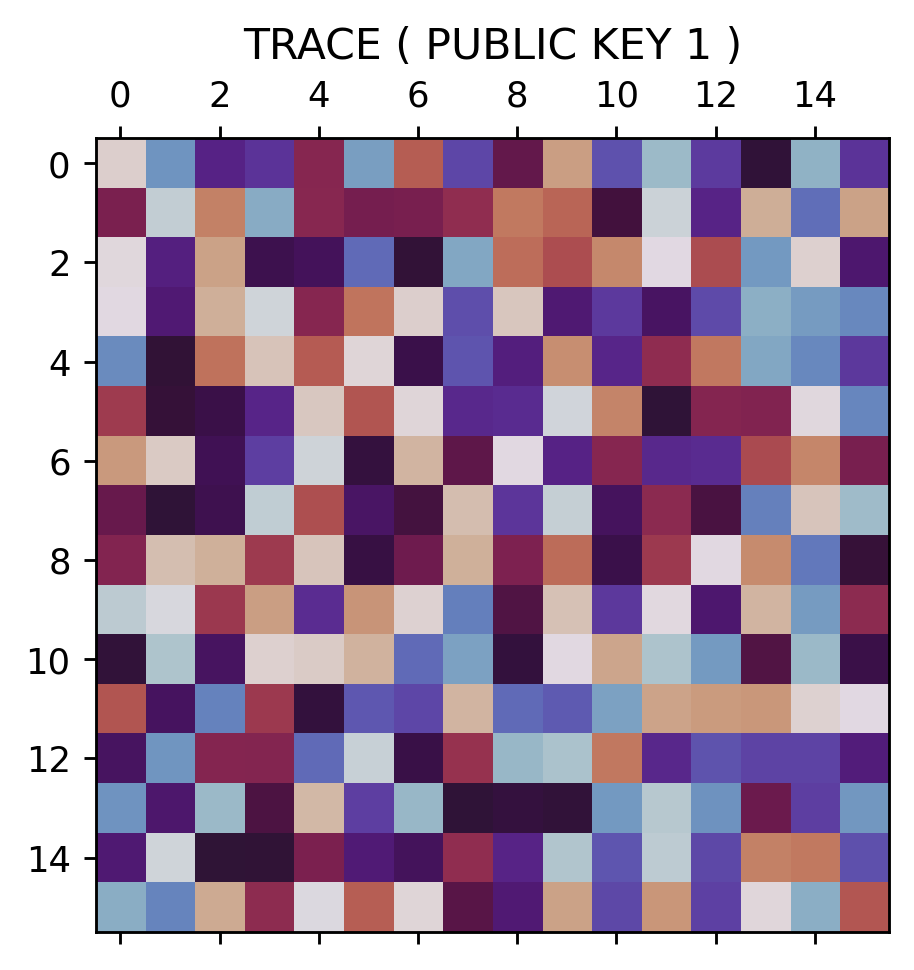

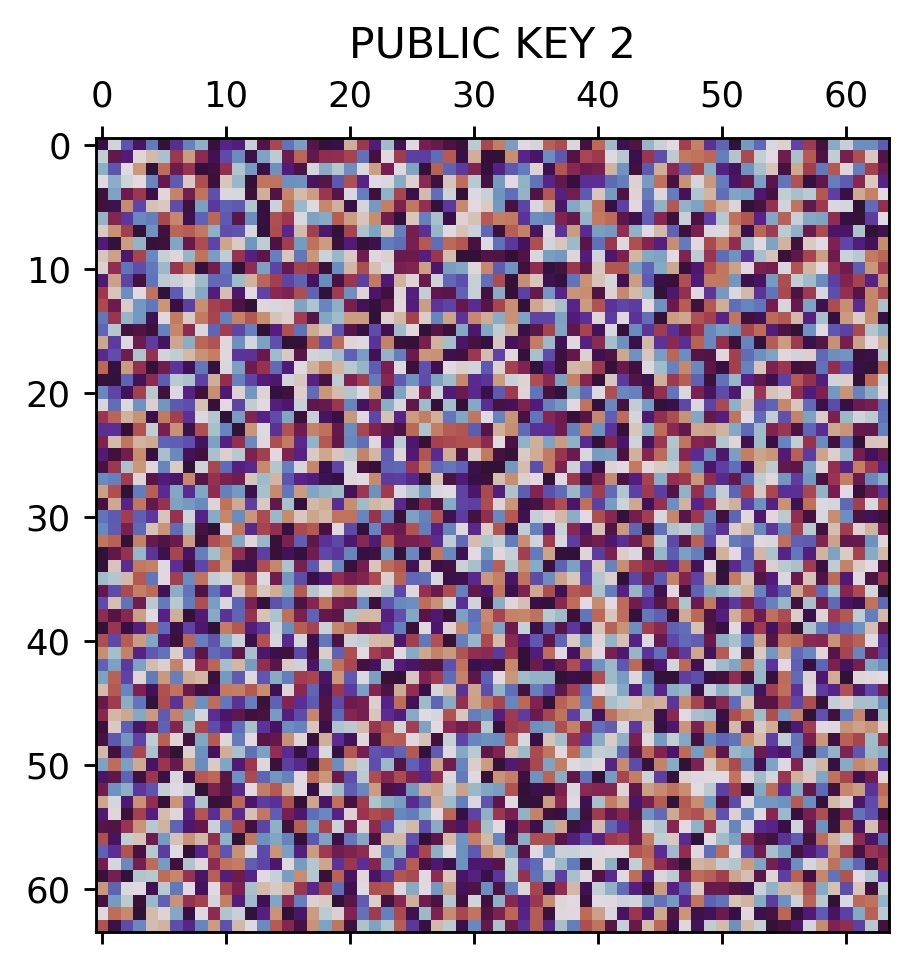

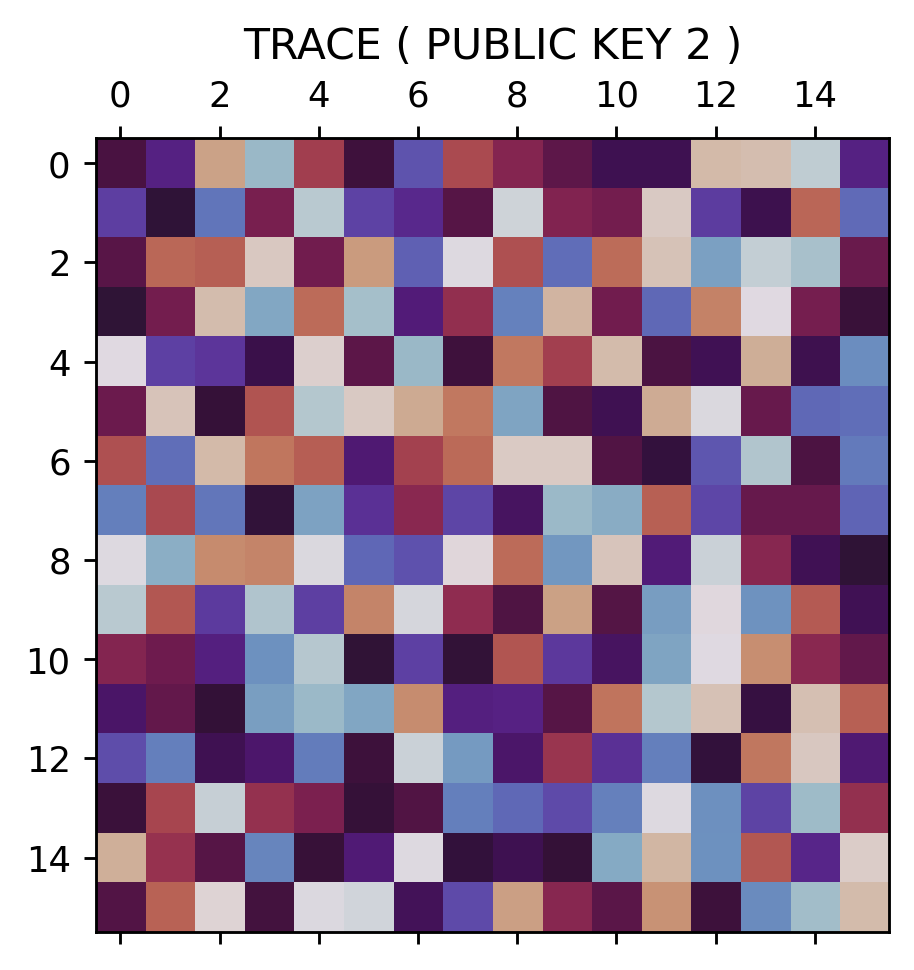

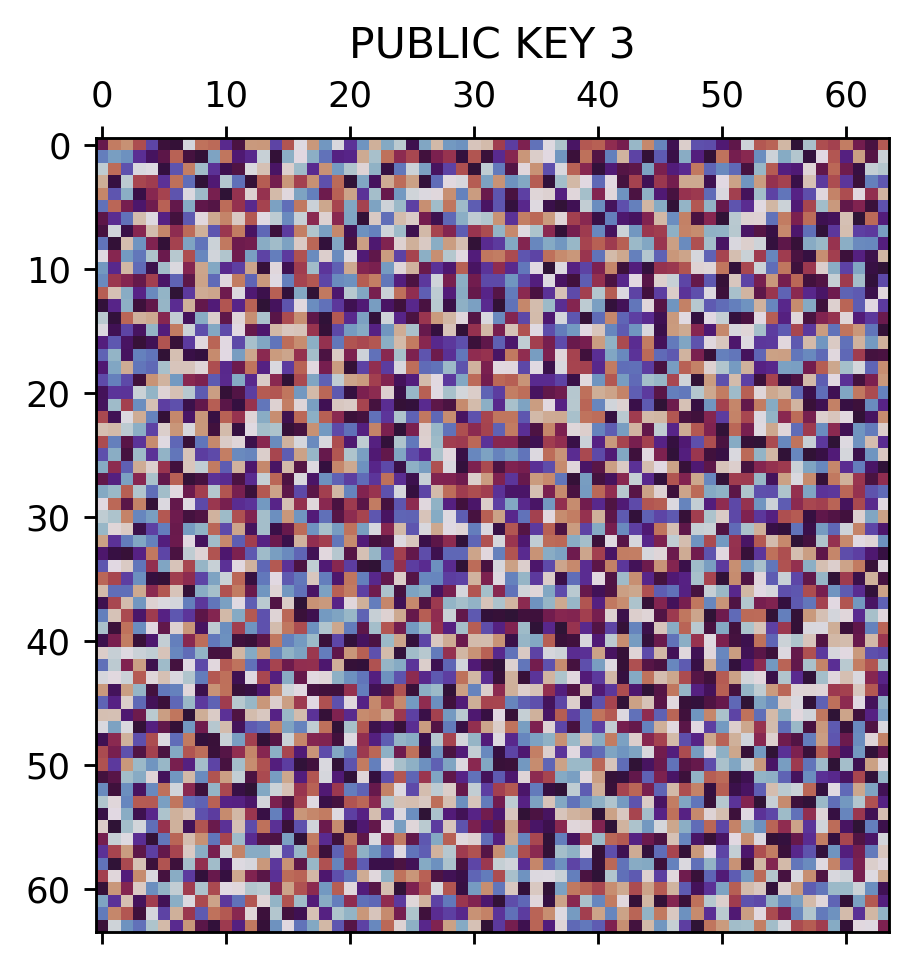

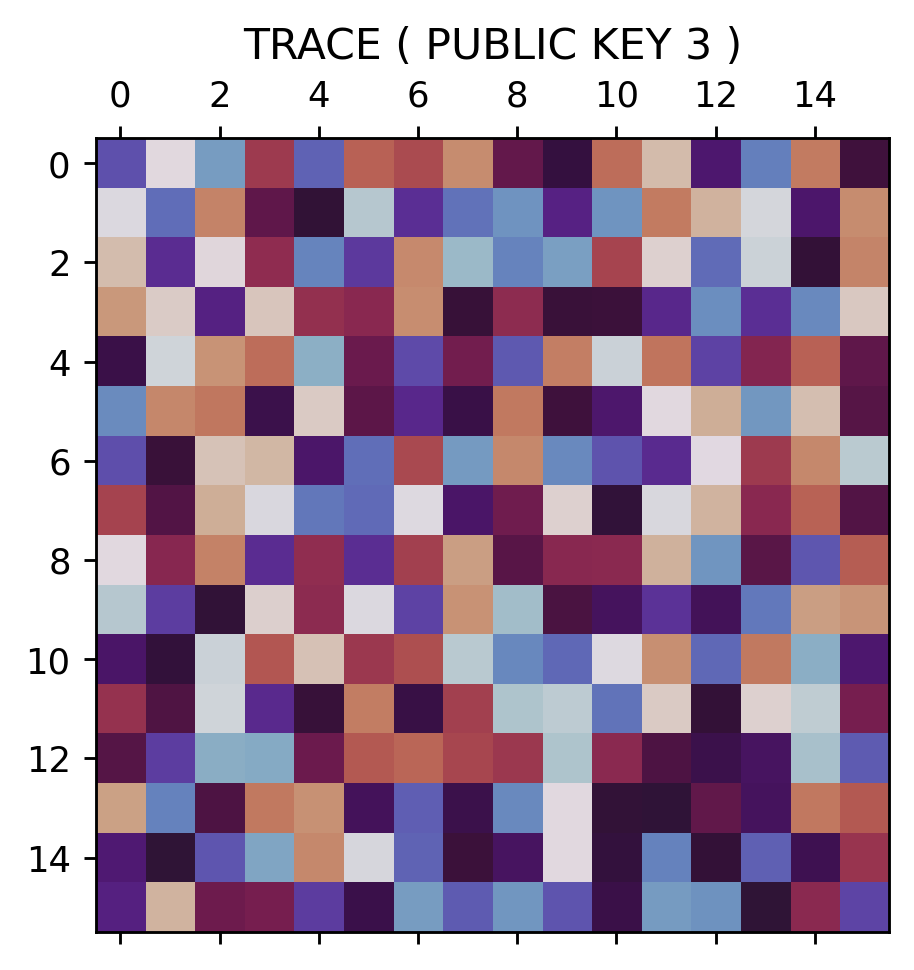

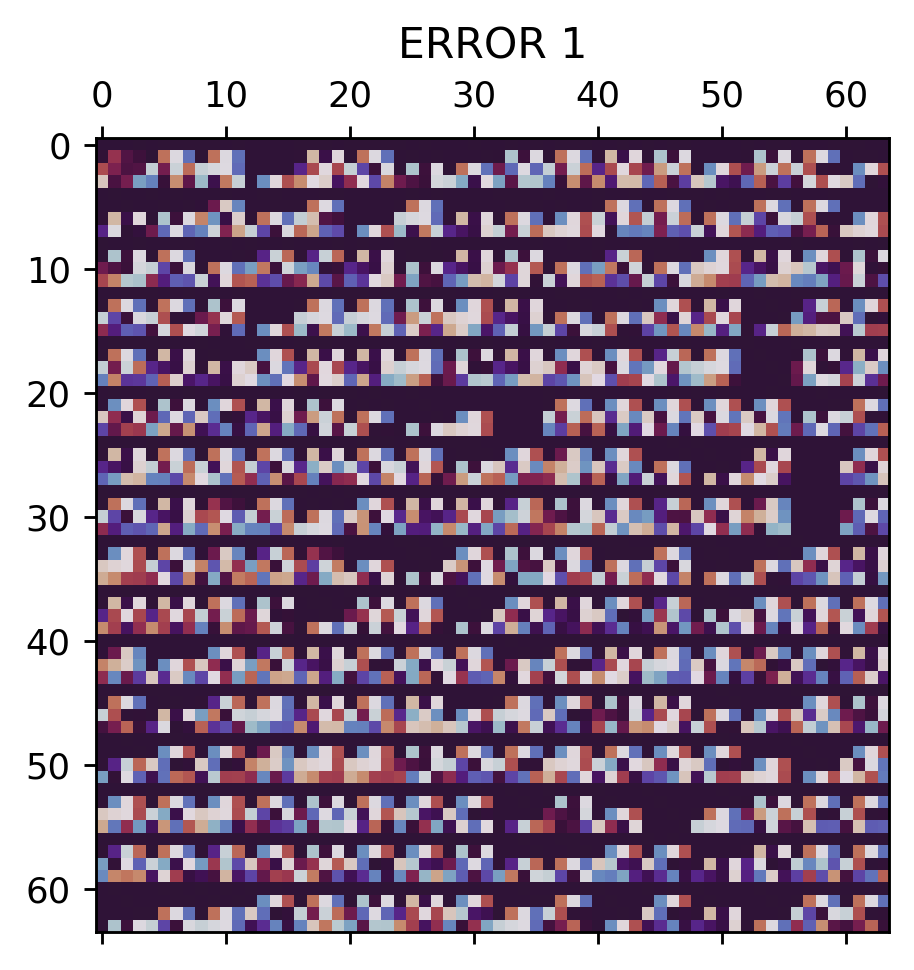

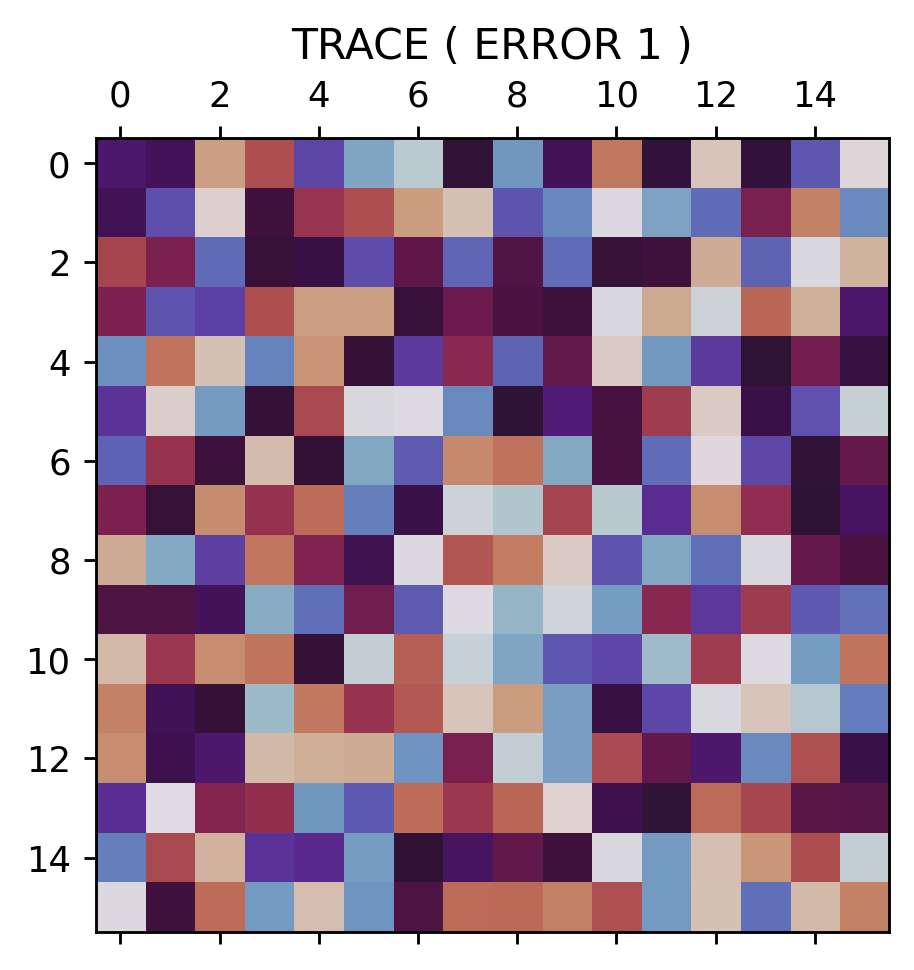

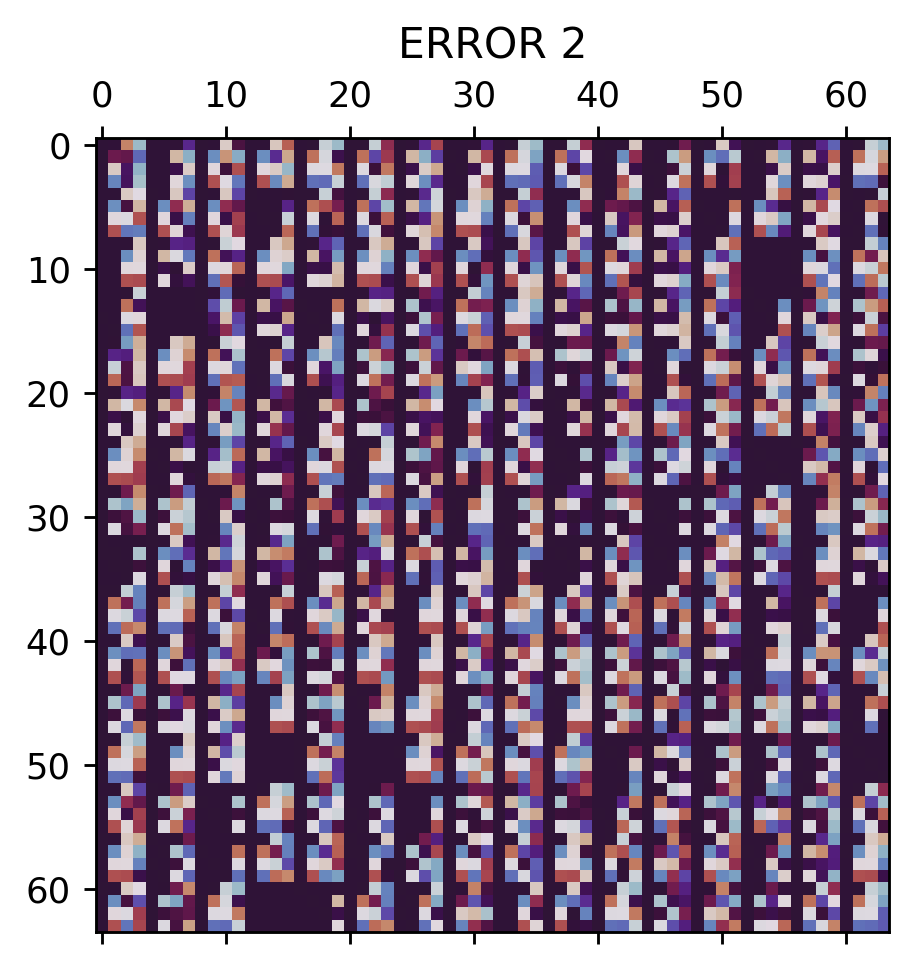

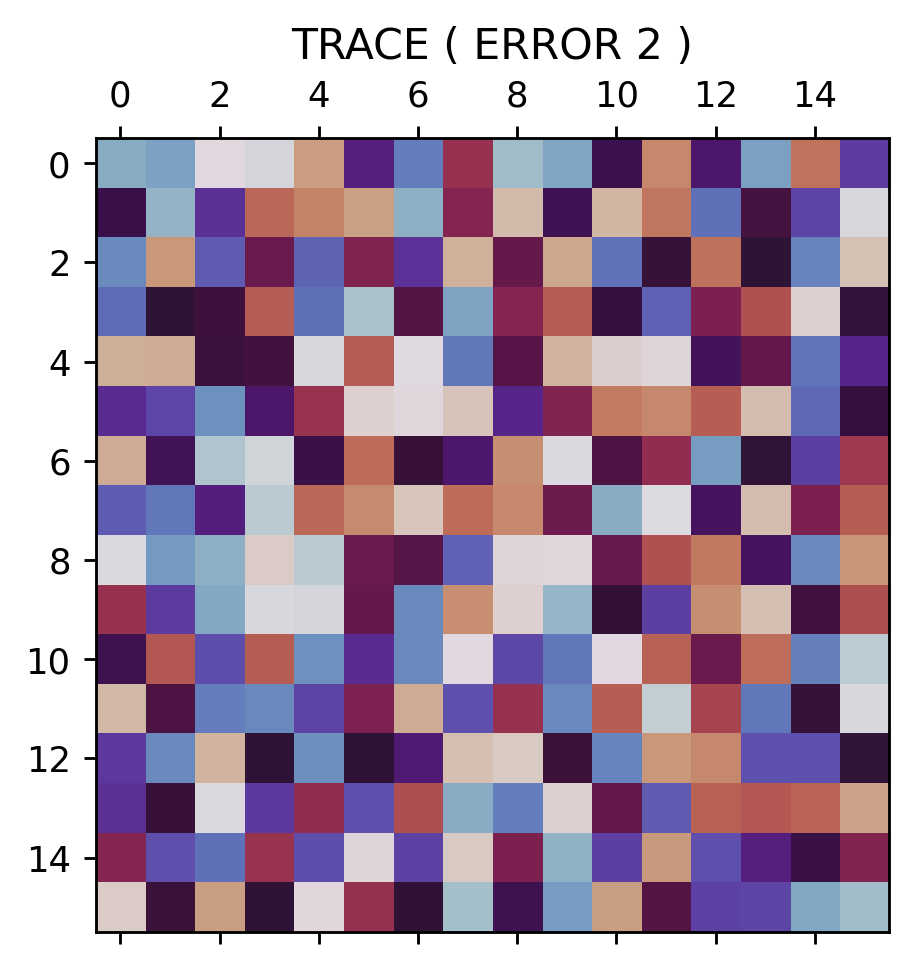

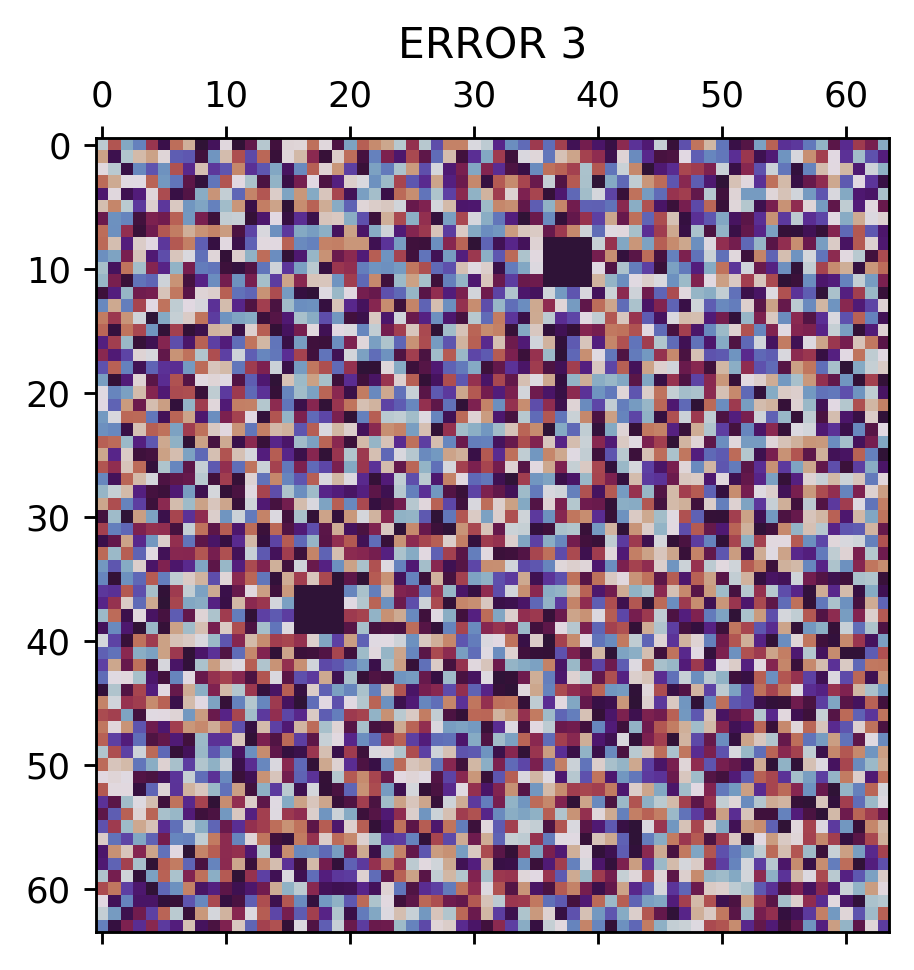

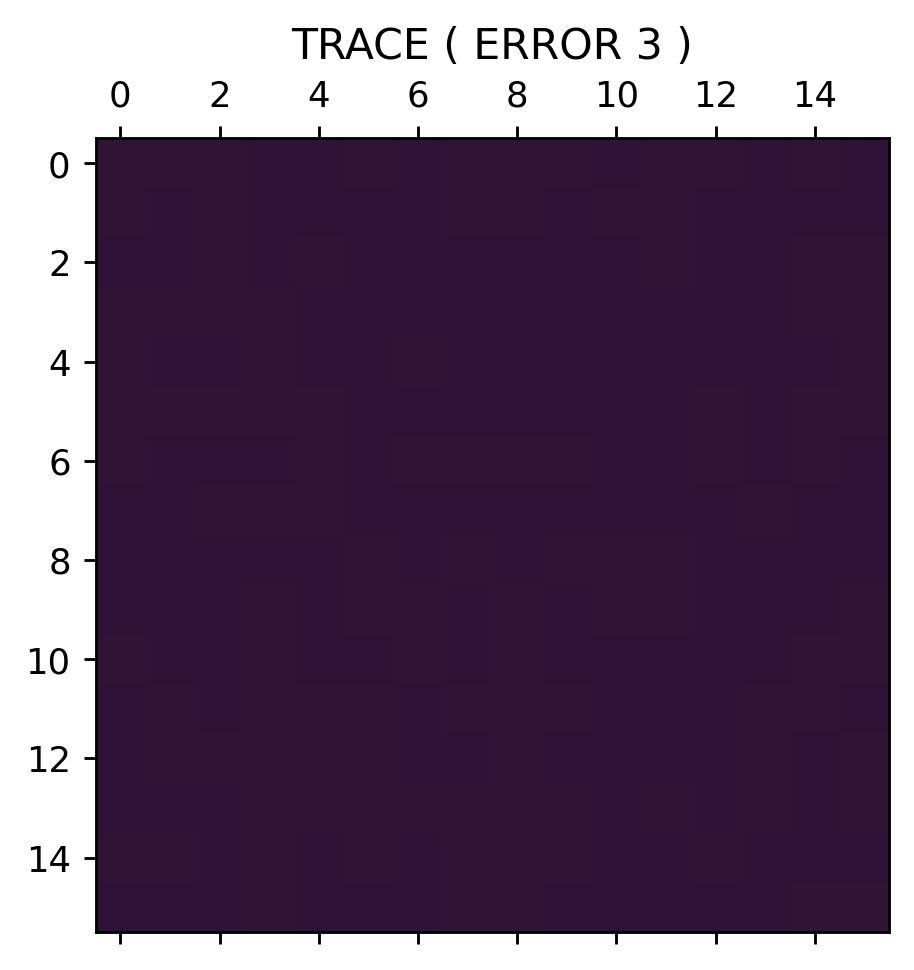

In [6]:
poppy.plot(poppy.trace(MU,p), title = 'MESSAGE')
poppy.plot(poppy.unblock(ct), title = 'ENCRYPTED MESSAGE')
poppy.plot(poppy.trace(ct,p), title = 'TRACE ( ENCRYPTED MESSAGE )')
poppy.plot(poppy.unblock(pk1), title = 'PUBLIC KEY 1')
poppy.plot(poppy.trace(pk1,p), title = 'TRACE ( PUBLIC KEY 1 )')
poppy.plot(poppy.unblock(pk2), title = 'PUBLIC KEY 2')
poppy.plot(poppy.trace(pk2,p), title = 'TRACE ( PUBLIC KEY 2 )')
poppy.plot(poppy.unblock(pk3), title = 'PUBLIC KEY 3')
poppy.plot(poppy.trace(pk3,p), title = 'TRACE ( PUBLIC KEY 3 )')
poppy.plot(poppy.unblock(e1), title = 'ERROR 1')
poppy.plot(poppy.trace(e1,p), title = 'TRACE ( ERROR 1 )')
poppy.plot(poppy.unblock(e2), title = 'ERROR 2')
poppy.plot(poppy.trace(e2,p), title = 'TRACE ( ERROR 2 )')
poppy.plot(poppy.unblock(e3), title = 'ERROR 3')
poppy.plot(poppy.trace(e3,p), title = 'TRACE ( ERROR 3 )')

In [7]:
print(f'\nPOWER BASIS TRACE\n{poppy.trace(f.basis,p)}')
print(f'\nDUAL BASIS TRACE\n{poppy.trace(f.dual,p)}')
print(f'\nPOWER x DUAL TRACE\n{poppy.trace(outer(f.basis,f.dual),p)}')


POWER BASIS TRACE
[   4 2529  955 2028]

DUAL BASIS TRACE
[1 0 0 0]

POWER x DUAL TRACE
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


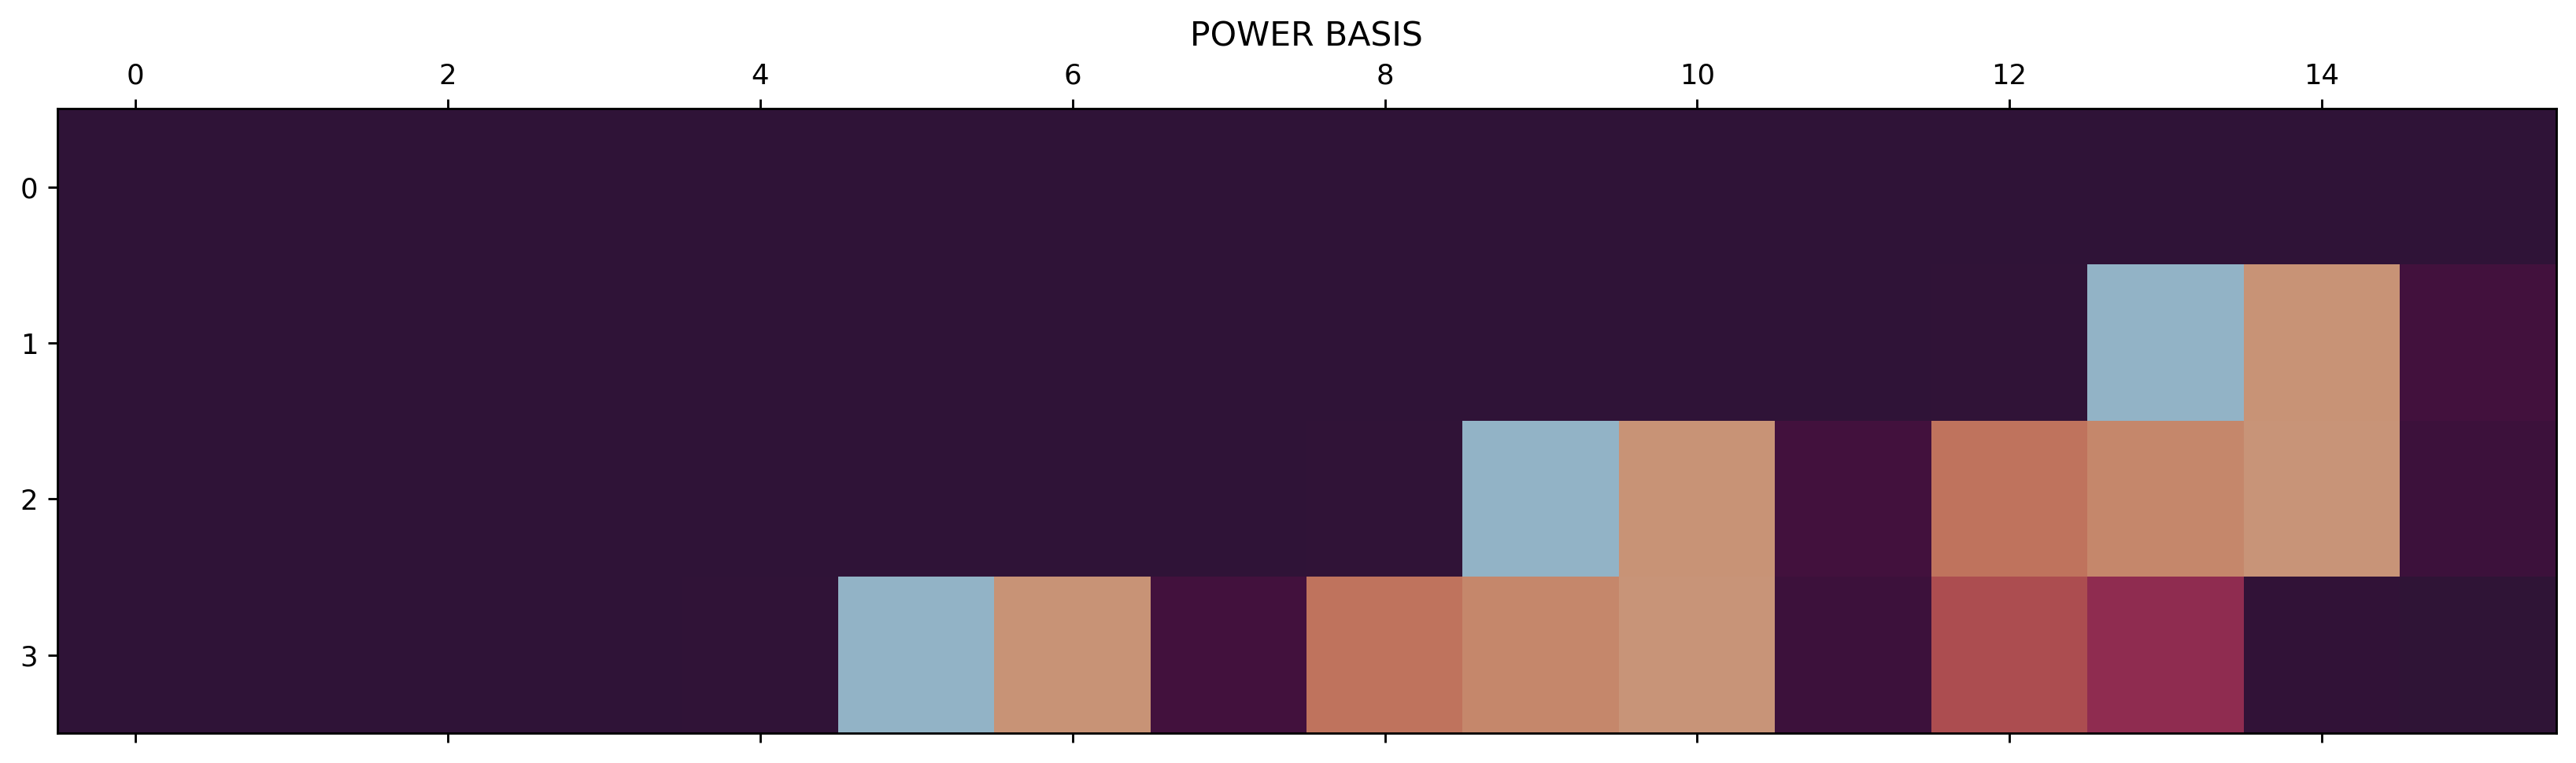

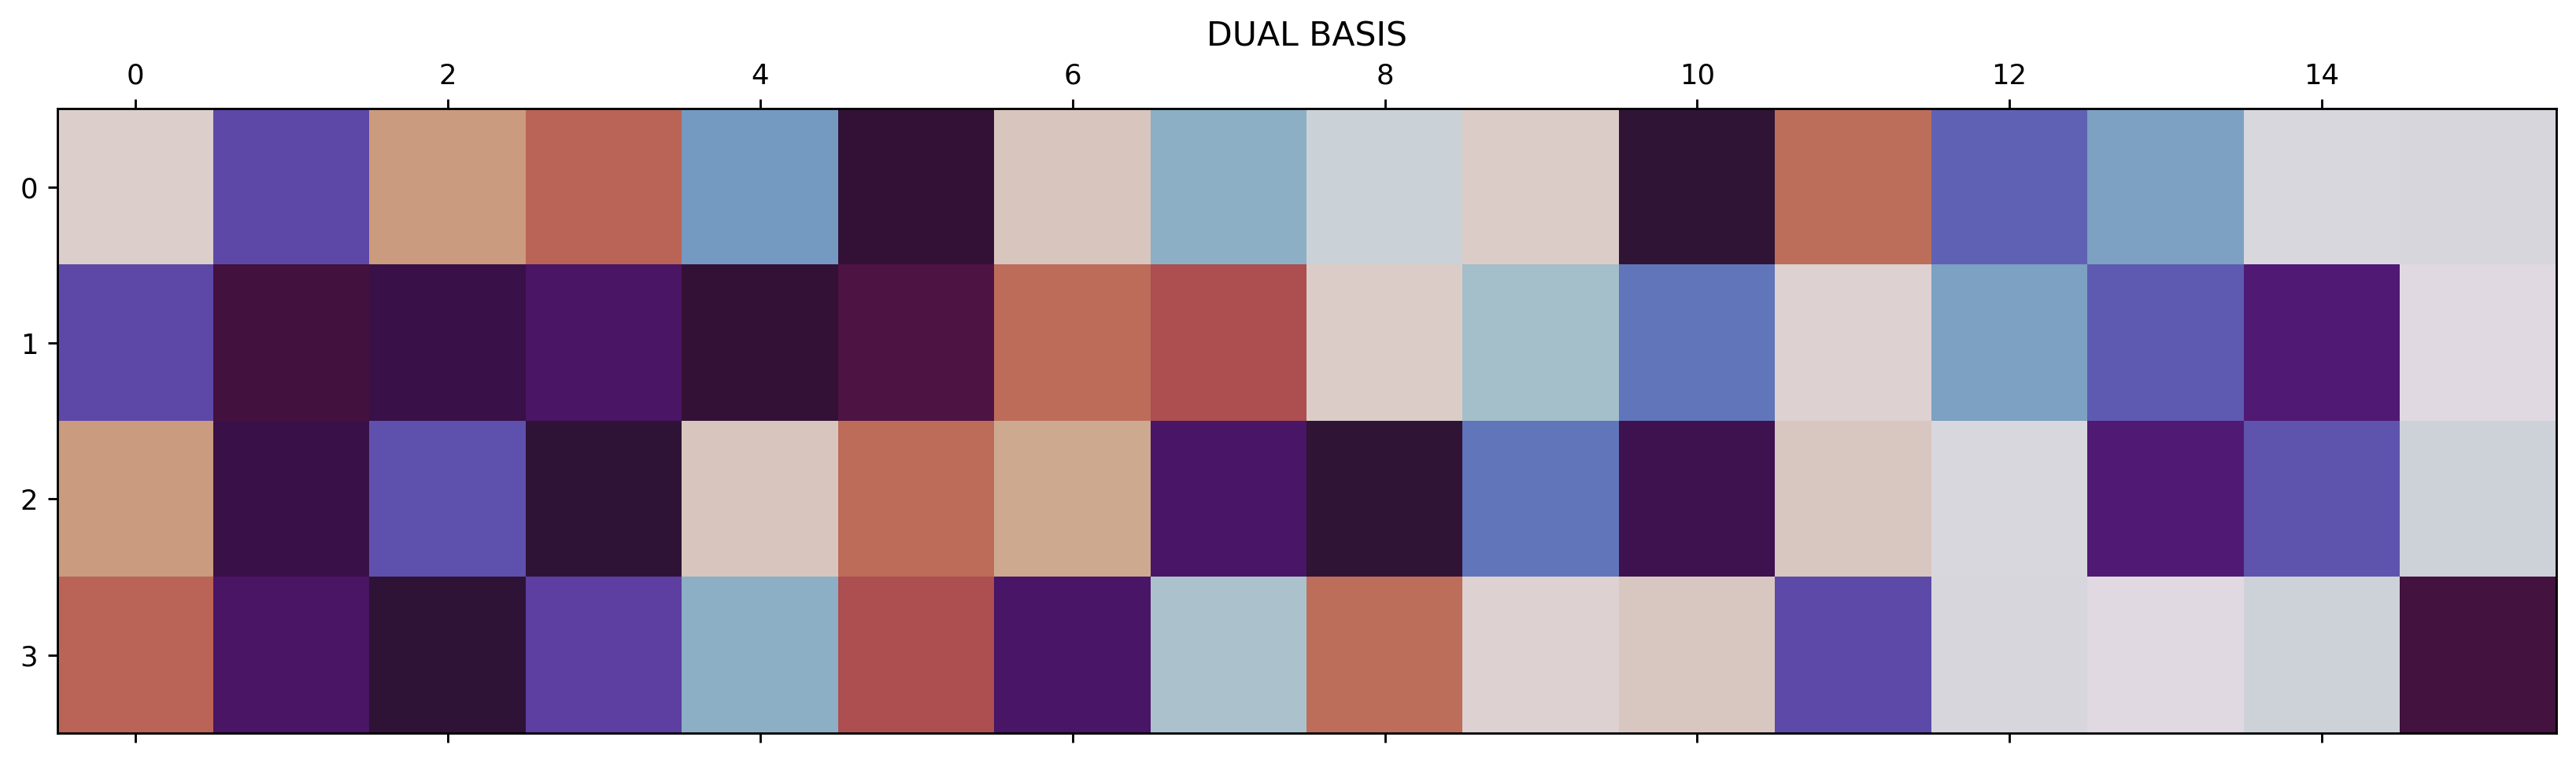

In [8]:
poppy.plot(f.basis, title = 'POWER BASIS')
poppy.plot(f.dual, title = 'DUAL BASIS')

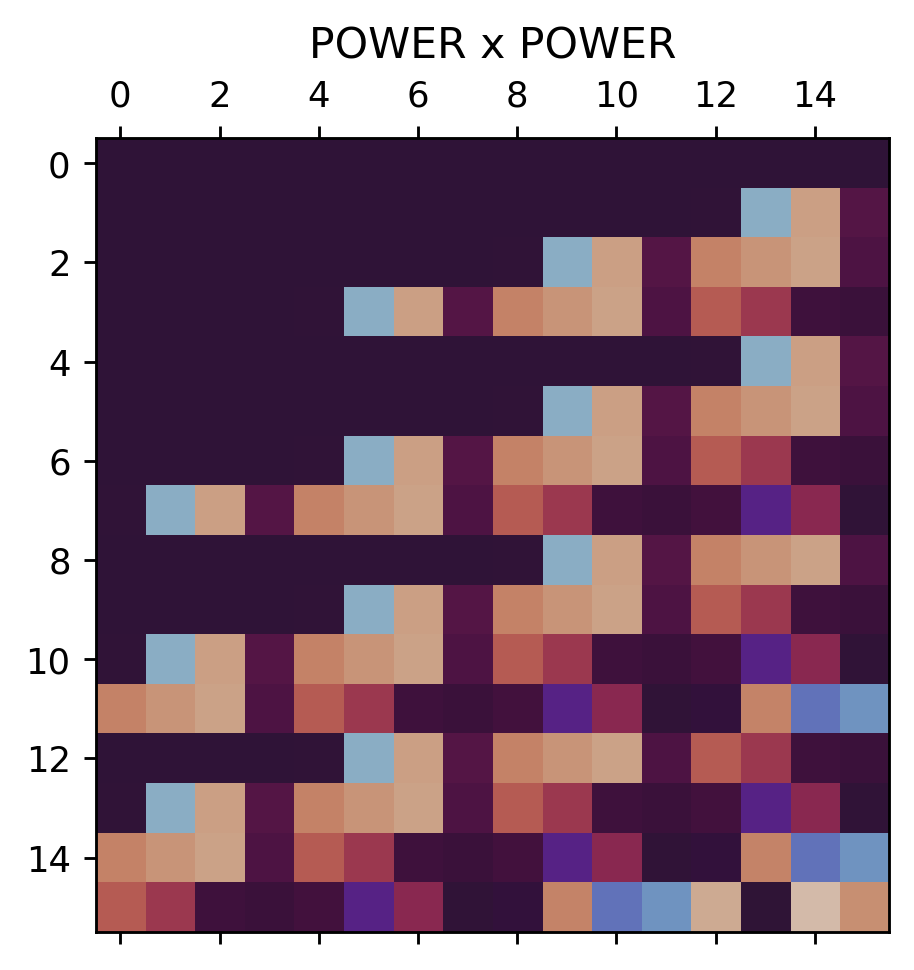

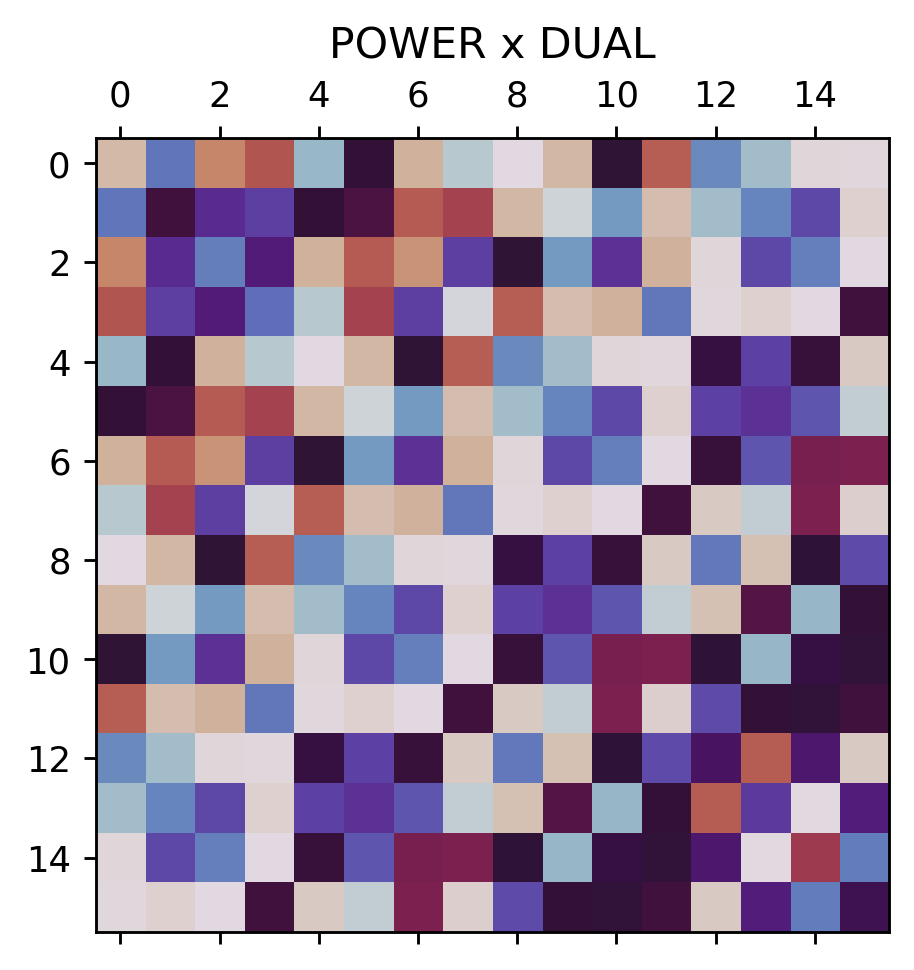

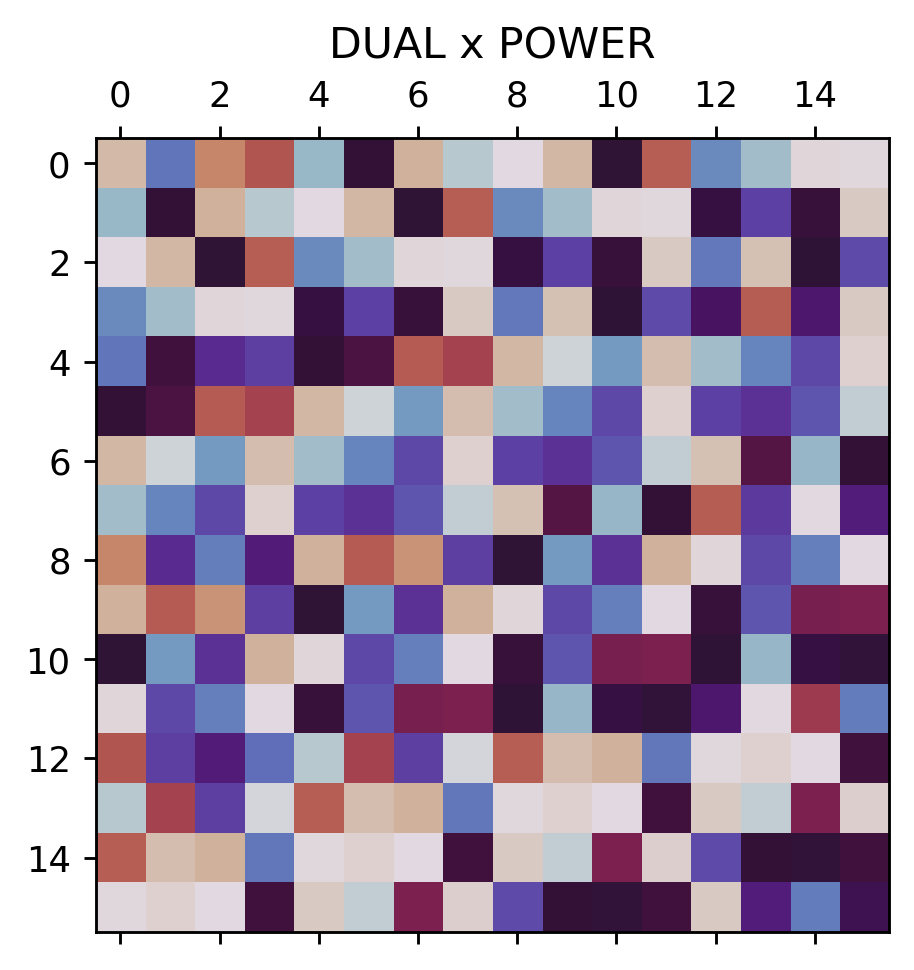

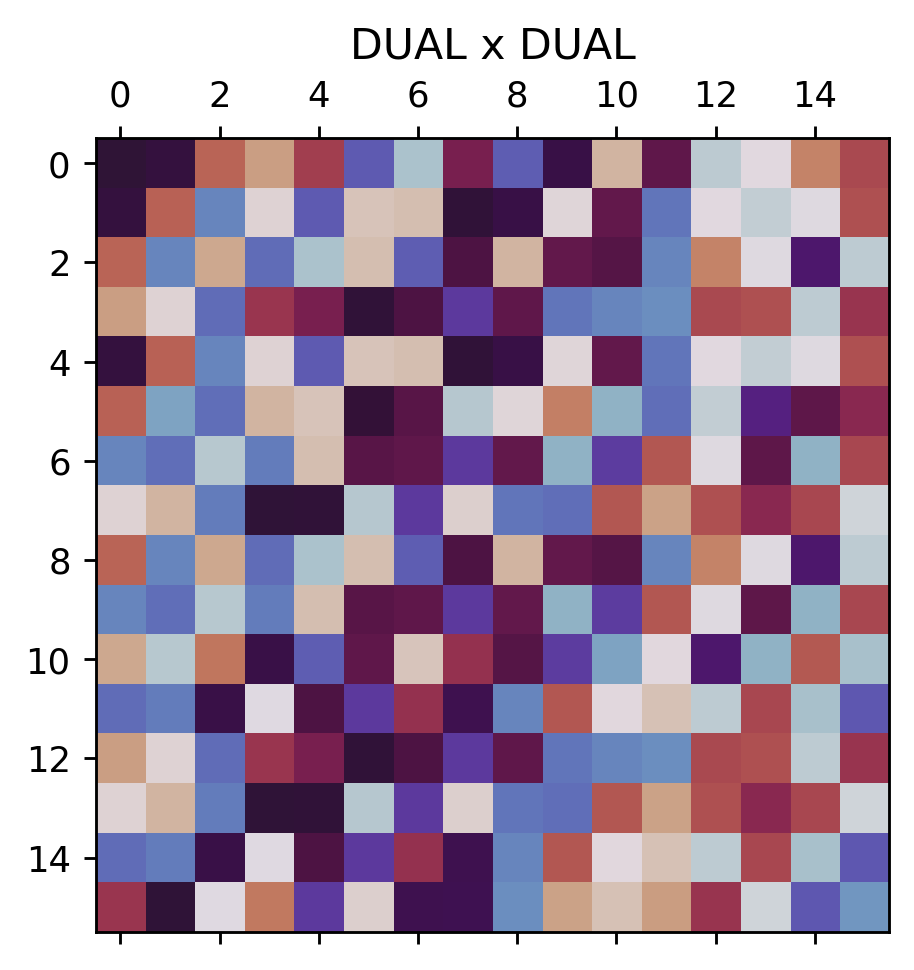

In [9]:
poppy.plot(outer(f.basis,f.basis), title = 'POWER x POWER')
poppy.plot(outer(f.basis,f.dual), title = 'POWER x DUAL')
poppy.plot(outer(f.dual,f.basis), title = 'DUAL x POWER')
poppy.plot(outer(f.dual,f.dual), title = 'DUAL x DUAL')

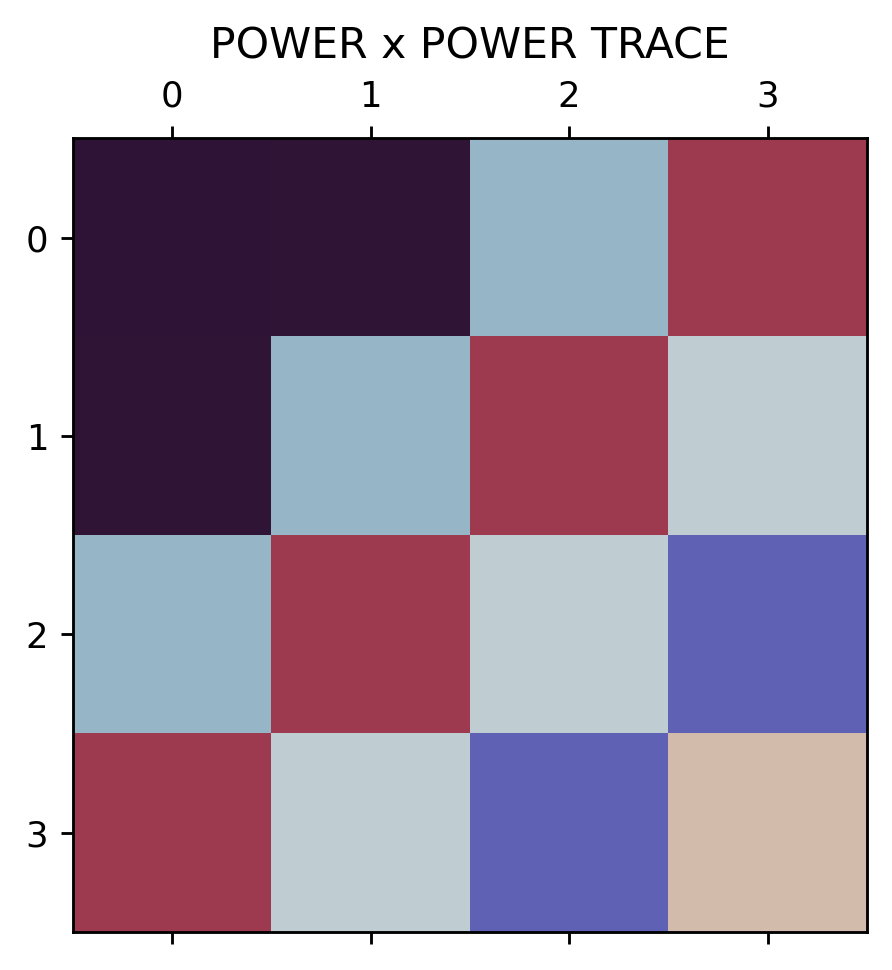

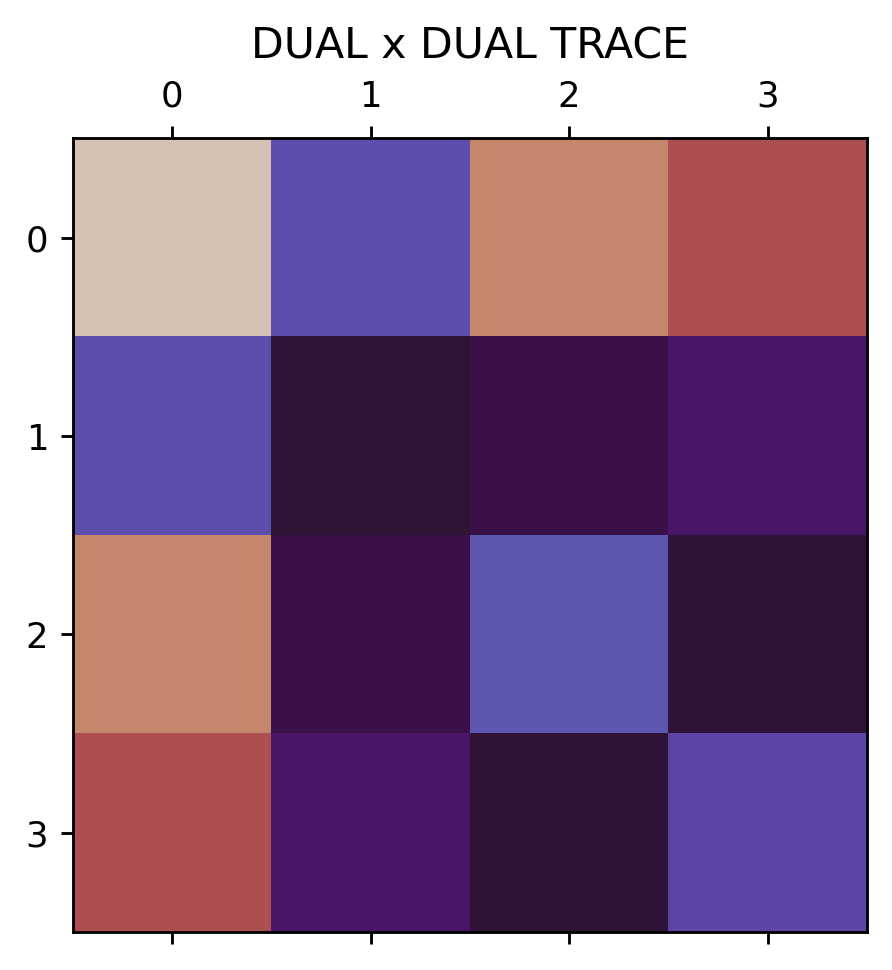

In [10]:
poppy.plot(poppy.trace(outer(f.basis,f.basis),p), title = 'POWER x POWER TRACE')
poppy.plot(poppy.trace(outer(f.dual,f.dual),p), title = 'DUAL x DUAL TRACE')